In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
%matplotlib inline

In [3]:
df = pd.read_excel("../data/sample_transactions.xlsx")

In [4]:
df.head()

,transaction_id,date,day_of_week,month,description,merchant,amount,category,payment_mode,transaction_channel,account_type,city,is_weekend,is_anomaly
0,TXN00001,2024-01-02,Tuesday,January,POS TXN 9289,Cafe Coffee Day,8123.00,Food,Cash,ATM,Savings,Delhi,False,True
1,TXN00002,2024-01-02,Tuesday,January,dunzo delivery,Dunzo,315.93,Food,NEFT,Web,Savings,Delhi,False,False
2,TXN00003,2024-01-02,Tuesday,January,property tax payment,BBMP,4619.46,Utilities,Debit Card,Auto Debit,Savings,Delhi,False,False
3,TXN00004,2024-01-02,Tuesday,January,monthly rent,Housing Society,14768.18,Rent,Net Banking,Auto Debit,Savings,Delhi,False,False
4,TXN00005,2024-01-02,Tuesday,January,monthly rent,Housing Society,20437.67,Rent,Auto Debit,Auto Debit,Savings,Delhi,False,False


In [4]:
df.shape

(1398, 14)

In [5]:
df.columns

Index(['transaction_id', 'date', 'day_of_week', 'month', 'description',
       'merchant', 'amount', 'category', 'payment_mode', 'transaction_channel',
       'account_type', 'city', 'is_weekend', 'is_anomaly'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1398 entries, 0 to 1397
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       1398 non-null   str    
 1   date                 1398 non-null   str    
 2   day_of_week          1398 non-null   str    
 3   month                1398 non-null   str    
 4   description          1398 non-null   str    
 5   merchant             1398 non-null   str    
 6   amount               1398 non-null   float64
 7   category             1398 non-null   str    
 8   payment_mode         1398 non-null   str    
 9   transaction_channel  1398 non-null   str    
 10  account_type         1398 non-null   str    
 11  city                 1398 non-null   str    
 12  is_weekend           1398 non-null   bool   
 13  is_anomaly           1398 non-null   bool   
dtypes: bool(2), float64(1), str(11)
memory usage: 250.7 KB


In [7]:
## cheickng data quality
df.isnull().sum()

transaction_id         0
date                   0
day_of_week            0
month                  0
description            0
merchant               0
amount                 0
category               0
payment_mode           0
transaction_channel    0
account_type           0
city                   0
is_weekend             0
is_anomaly             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
## fixing date column
# we need to convert the date column to somerthing that panda understands
# currently it is just a string for pandas, so we need to change it to actual datetime object

df['date'] = pd.to_datetime(df['date'])
print(df['date'].head())
print(df['date'].dtype)

0   2024-01-02
1   2024-01-02
2   2024-01-02
3   2024-01-02
4   2024-01-02
Name: date, dtype: datetime64[us]
datetime64[us]


In [10]:
## now we will use .dt.month to extacrt the month from 1-12 and give them name like jan, feb
# using strftime(%b)

df['month_num'] = df['date'].dt.month
df['month_label'] = df['date'].dt.strftime('%b')

print(df[['date', 'month_num', 'month_label']].head(10))
# print(df.head())

        date  month_num month_label
0 2024-01-02          1         Jan
1 2024-01-02          1         Jan
2 2024-01-02          1         Jan
3 2024-01-02          1         Jan
4 2024-01-02          1         Jan
5 2024-01-03          1         Jan
6 2024-01-03          1         Jan
7 2024-01-03          1         Jan
8 2024-01-03          1         Jan
9 2024-01-04          1         Jan


## exploratory data analysis
total transactions = 540
categories = 15
months =- 12

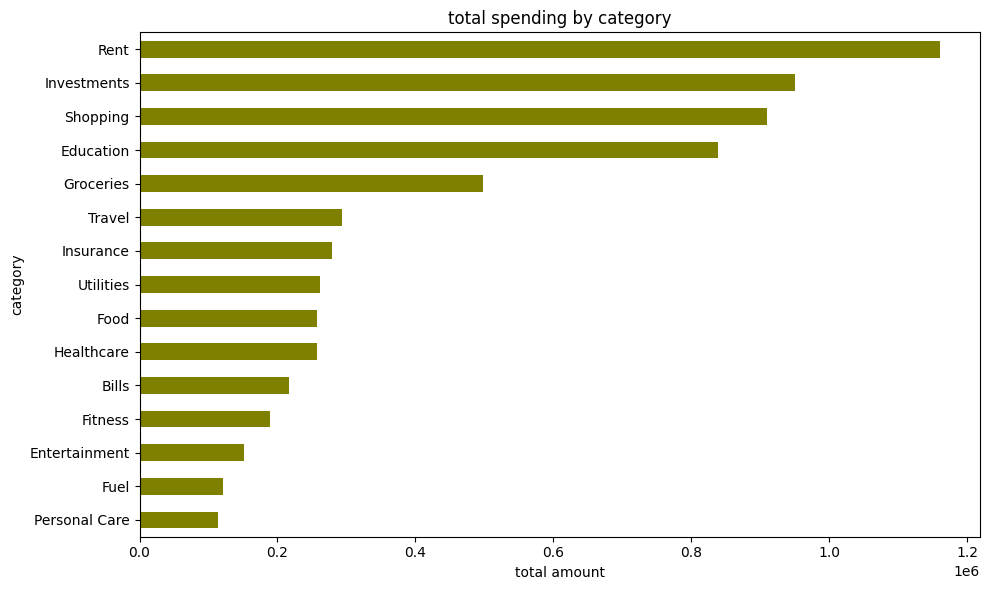

In [11]:
## Chart1: spendings by category

cat_spend = df.groupby('category')['amount'].sum().sort_values()

# groupby category feature
## within each category we will sum the values in amount column
# then sort in ascending values

plt.figure(figsize=(10,6))
cat_spend.plot(kind='barh', color='olive')
plt.title("total spending by category")
plt.xlabel('total amount')
plt.ylabel("category")
plt.tight_layout()
plt.show()

### insight: categorty spending

- investments, education and rent are the categories with highest spendings
- food has the lowest total, which means small frequent transactions

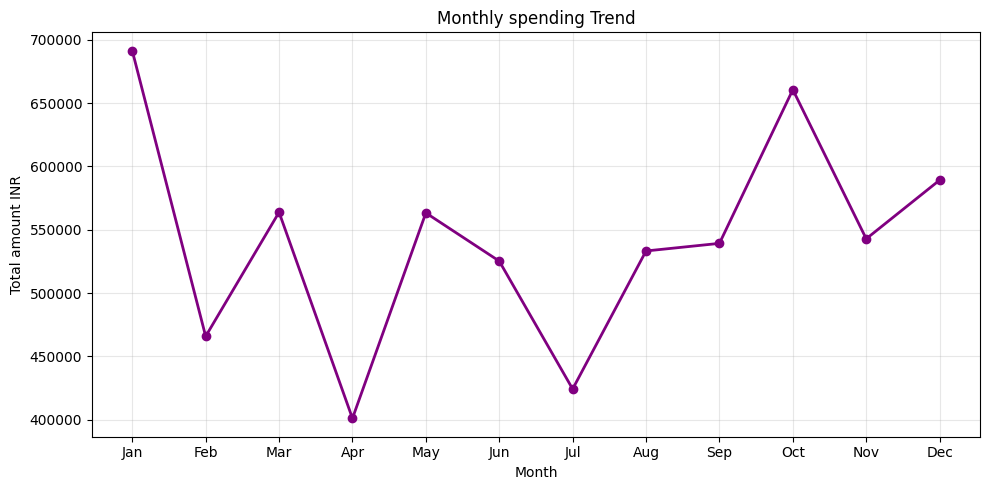

In [12]:
## chart2 : monthly trends

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct','Nov', 'Dec']

monthly = df.groupby('month_num')['amount'].sum().reset_index()
#.reset_index() Converts the grouped result back into a DataFrame instead of a Series.

monthly['month_label'] = monthly['month_num'].apply(lambda x: month_order[x-1])
## .apply() runs a function on each element of column
## lambda is an inline function where, for each value of x, lambda will compute something
## that something is [x-1], as the list in python starts from 0 index so we do -1 to  align
# it with the numbering of months
monthly = monthly.sort_values('month_num')

plt.figure(figsize=(10,5))
plt.plot(monthly['month_label'], monthly['amount'], marker='o', linewidth=2, color='purple')
plt.title('Monthly spending Trend')
plt.xlabel("Month")
plt.ylabel('Total amount INR')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Insight for spending per month

- Spending peaks in april — likely annual payments like insurance or subscriptions
- while lowest spendings where dne in jan, sept and nov

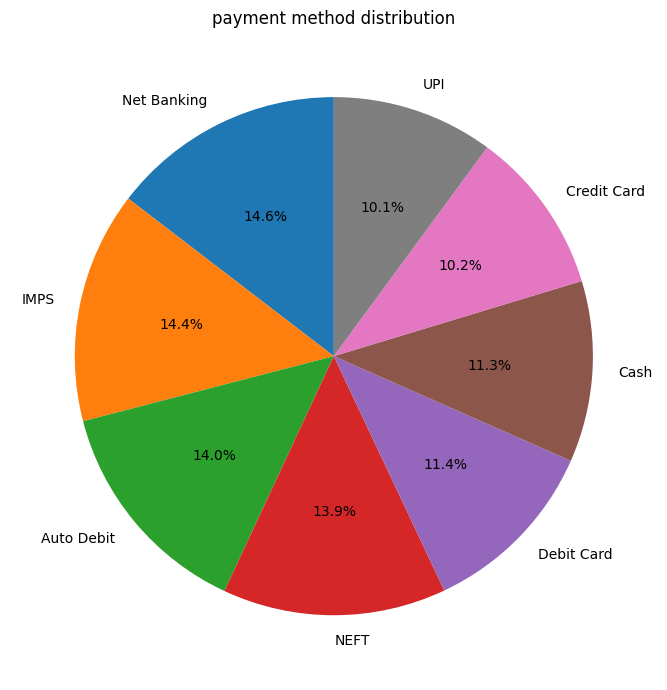

In [13]:
## chart3 : payment mode

payment_counts = df['payment_mode'].value_counts()
## payment_counts is a Pandas Series where the index is the payment mode and the values are the counts.

plt.figure(figsize=(7,7))
plt.pie(payment_counts.values,
        labels=payment_counts.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title("payment method distribution")
plt.tight_layout()
plt.show()

### Insights for payment methods

- cash is used the most, followed by net bankiing
- least used method is debit card

In [14]:
df.head()

,transaction_id,date,day_of_week,month,description,merchant,amount,category,payment_mode,transaction_channel,account_type,city,is_weekend,is_anomaly,month_num,month_label
0,TXN00001,2024-01-02,Tuesday,January,POS TXN 9289,Cafe Coffee Day,8123.00,Food,Cash,ATM,Savings,Delhi,False,True,1,Jan
1,TXN00002,2024-01-02,Tuesday,January,dunzo delivery,Dunzo,315.93,Food,NEFT,Web,Savings,Delhi,False,False,1,Jan
2,TXN00003,2024-01-02,Tuesday,January,property tax payment,BBMP,4619.46,Utilities,Debit Card,Auto Debit,Savings,Delhi,False,False,1,Jan
3,TXN00004,2024-01-02,Tuesday,January,monthly rent,Housing Society,14768.18,Rent,Net Banking,Auto Debit,Savings,Delhi,False,False,1,Jan
4,TXN00005,2024-01-02,Tuesday,January,monthly rent,Housing Society,20437.67,Rent,Auto Debit,Auto Debit,Savings,Delhi,False,False,1,Jan


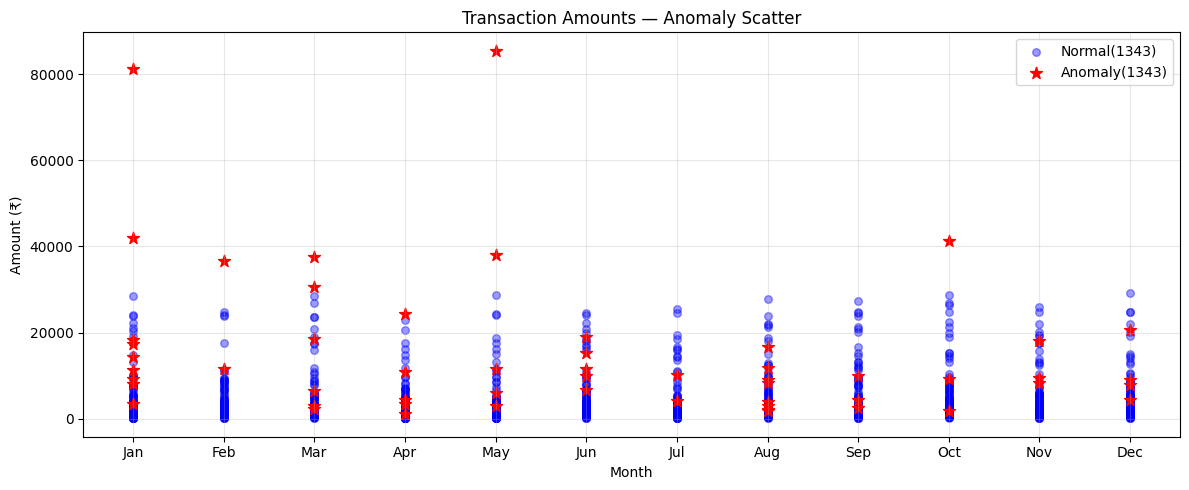

In [15]:
## chart4: Anomaly
normal = df[df['is_anomaly']== False]
anomalies = df[df['is_anomaly'] == True]

plt.figure(figsize=(12,5))

plt.scatter(normal['month_num'], normal['amount'], alpha=0.4, color='blue', label=f'Normal({len(normal)})',s=30)
plt.scatter(anomalies['month_num'], anomalies['amount'], alpha=1.0, color='red',marker='*', label=f'Anomaly({len(normal)})',s=80)

#alpha=0.4  Semi-transparent points (so overlapping points are visible)
# s means marker size

plt.xticks(range(1, 13), month_order)
plt.title('Transaction Amounts — Anomaly Scatter')
plt.xlabel('Month')
plt.ylabel('Amount (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
anomalies.shape

(55, 16)

### insights for anomalies
35 anomalous transactions were detected 

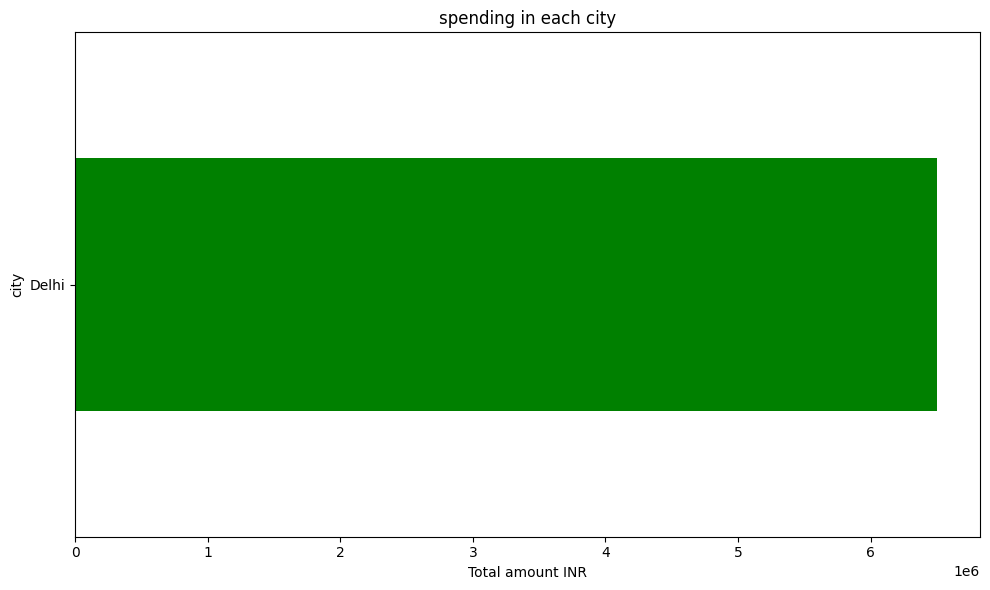

In [17]:
## chart 5: ttal spendin g by city

city_spend = df.groupby('city')['amount'].sum().sort_values()

plt.figure(figsize=(10,6))
city_spend.plot(kind="barh", color="green")

plt.title("spending in each city")
plt.xlabel("Total amount INR")
plt.tight_layout()
plt.show()

### insights for spendings in each city
- kolkata and delhi had highest spendings, followed by hyderabad
- jaipur had lowest spendings